# Analyse Exploratoire

### Import des modules

In [1]:
import pandas as pd
import numpy as np
import math
import seaborn as sns 
import matplotlib.pyplot as plt

### Analyse Exploratoire

In [2]:
consumption_df = pd.read_csv("data/2016_Building_Energy_Benchmarking.csv") #fichier original csv

In [3]:
# On regarde comment un batiment est défini dans ce jeu de données 
consumption_df.head()

,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,TaxParcelIdentificationNumber,...,Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,Comments,ComplianceStatus,Outlier,TotalGHGEmissions,GHGEmissionsIntensity
0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,0659000030,...,1.156514e+06,3946027.0,12764.52930,1276453.0,False,NaN,Compliant,NaN,249.98,2.83
1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,0659000220,...,9.504252e+05,3242851.0,51450.81641,5145082.0,False,NaN,Compliant,NaN,295.86,2.86
2,3,2016,NonResidential,Hotel,5673-The Westin Seattle,1900 5th Avenue,Seattle,WA,98101.0,0659000475,...,1.451544e+07,49526664.0,14938.00000,1493800.0,False,NaN,Compliant,NaN,2089.28,2.19
3,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,0659000640,...,8.115253e+05,2768924.0,18112.13086,1811213.0,False,NaN,Compliant,NaN,286.43,4.67
4,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,0659000970,...,1.573449e+06,5368607.0,88039.98438,8803998.0,False,NaN,Compliant,NaN,505.01,2.88


In [4]:
# On regarde le nombre de valeurs manquantes par colonne ainsi que leur type 
consumption_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3376 entries, 0 to 3375
Data columns (total 46 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   OSEBuildingID                    3376 non-null   int64  
 1   DataYear                         3376 non-null   int64  
 2   BuildingType                     3376 non-null   object 
 3   PrimaryPropertyType              3376 non-null   object 
 4   PropertyName                     3376 non-null   object 
 5   Address                          3376 non-null   object 
 6   City                             3376 non-null   object 
 7   State                            3376 non-null   object 
 8   ZipCode                          3360 non-null   float64
 9   TaxParcelIdentificationNumber    3376 non-null   object 
 10  CouncilDistrictCode              3376 non-null   int64  
 11  Neighborhood                     3376 non-null   object 
 12  Latitude            

In [5]:
consumption_df.columns

Index(['OSEBuildingID', 'DataYear', 'BuildingType', 'PrimaryPropertyType',
       'PropertyName', 'Address', 'City', 'State', 'ZipCode',
       'TaxParcelIdentificationNumber', 'CouncilDistrictCode', 'Neighborhood',
       'Latitude', 'Longitude', 'YearBuilt', 'NumberofBuildings',
       'NumberofFloors', 'PropertyGFATotal', 'PropertyGFAParking',
       'PropertyGFABuilding(s)', 'ListOfAllPropertyUseTypes',
       'LargestPropertyUseType', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseType', 'SecondLargestPropertyUseTypeGFA',
       'ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA',
       'YearsENERGYSTARCertified', 'ENERGYSTARScore', 'SiteEUI(kBtu/sf)',
       'SiteEUIWN(kBtu/sf)', 'SourceEUI(kBtu/sf)', 'SourceEUIWN(kBtu/sf)',
       'SiteEnergyUse(kBtu)', 'SiteEnergyUseWN(kBtu)', 'SteamUse(kBtu)',
       'Electricity(kWh)', 'Electricity(kBtu)', 'NaturalGas(therms)',
       'NaturalGas(kBtu)', 'DefaultData', 'Comments', 'ComplianceStatus',
       'Outlier

In [6]:
consumption_df.shape

(3376, 46)

Le dataset contient 3376 observations et 46 variables décrivant les bâtiments non résidentiels de la ville de Seattle en 2016.

**`Ces variables regroupent plusieurs types d’informations :`**

**Des variables d’identification** (OSEBuildingID, Address, PropertyName) qui permettent uniquement d’identifier les bâtiments et ne seront pas utilisées pour la modélisation.

**Des variables structurelles** (PropertyGFATotal, NumberofFloors, YearBuilt) décrivant les caractéristiques physiques des bâtiments. Ces variables sont pertinentes car elles influencent directement la consommation énergétique.

**Des variables d’usage** (PrimaryPropertyType, BuildingType, Neighborhood) qui renseignent sur la fonction et la localisation des bâtiments.

**Des variables énergétiques** (SiteEnergyUse(kBtu), Electricity(kWh), NaturalGas(kBtu)) qui mesurent la consommation d’énergie.

**Des variables environnementales** (TotalGHGEmissions, GHGEmissionsIntensity) qui mesurent l’impact carbone des bâtiments et constituent des cibles potentielles pour la modélisation.

Dans le cadre du projet, l’objectif est de prédire la consommation énergétique et les émissions de CO2 à partir des caractéristiques structurelles des bâtiments.

In [7]:
consumption_df.describe()

,OSEBuildingID,DataYear,ZipCode,CouncilDistrictCode,Latitude,Longitude,YearBuilt,NumberofBuildings,NumberofFloors,PropertyGFATotal,...,SiteEnergyUse(kBtu),SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),Comments,TotalGHGEmissions,GHGEmissionsIntensity
count,3376.000000,3376.0,3360.000000,3376.000000,3376.000000,3376.000000,3376.000000,3368.000000,3376.000000,3.376000e+03,...,3.371000e+03,3.370000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,3.367000e+03,0.0,3367.000000,3367.000000
mean,21208.991114,2016.0,98116.949107,4.439277,47.624033,-122.334795,1968.573164,1.106888,4.709123,9.483354e+04,...,5.403667e+06,5.276726e+06,2.745959e+05,1.086639e+06,3.707612e+06,1.368505e+04,1.368505e+06,NaN,119.723971,1.175916
std,12223.757015,0.0,18.615205,2.120625,0.047758,0.027203,33.088156,2.108402,5.494465,2.188376e+05,...,2.161063e+07,1.593879e+07,3.912173e+06,4.352478e+06,1.485066e+07,6.709781e+04,6.709781e+06,NaN,538.832227,1.821452
min,1.000000,2016.0,98006.000000,1.000000,47.499170,-122.414250,1900.000000,0.000000,0.000000,1.128500e+04,...,0.000000e+00,0.000000e+00,0.000000e+00,-3.382680e+04,-1.154170e+05,0.000000e+00,0.000000e+00,NaN,-0.800000,-0.020000
25%,19990.750000,2016.0,98105.000000,3.000000,47.599860,-122.350662,1948.000000,1.000000,2.000000,2.848700e+04,...,9.251286e+05,9.701822e+05,0.000000e+00,1.874229e+05,6.394870e+05,0.000000e+00,0.000000e+00,NaN,9.495000,0.210000
50%,23112.000000,2016.0,98115.000000,4.000000,47.618675,-122.332495,1975.000000,1.000000,4.000000,4.417500e+04,...,1.803753e+06,1.904452e+06,0.000000e+00,3.451299e+05,1.177583e+06,3.237538e+03,3.237540e+05,NaN,33.920000,0.610000
75%,25994.250000,2016.0,98122.000000,7.000000,47.657115,-122.319407,1997.000000,1.000000,5.000000,9.099200e+04,...,4.222455e+06,4.381429e+06,0.000000e+00,8.293178e+05,2.829632e+06,1.189033e+04,1.189034e+06,NaN,93.940000,1.370000
max,50226.000000,2016.0,98272.000000,7.000000,47.733870,-122.220966,2015.000000,111.000000,99.000000,9.320156e+06,...,8.739237e+08,4.716139e+08,1.349435e+08,1.925775e+08,6.570744e+08,2.979090e+06,2.979090e+08,NaN,16870.980000,34.090000


L’analyse statistique descriptive met en évidence plusieurs valeurs incohérentes dans le dataset :

- Certaines consommations énergétiques sont égales à 0, ce qui est peu réaliste pour des bâtiments en activité.
- Des valeurs négatives apparaissent dans Electricity(kWh) et TotalGHGEmissions, ce qui est physiquement impossible.
- Le nombre d’étages et le nombre de bâtiments présentent des valeurs nulles, suggérant des erreurs de saisie ou des données manquantes.
- La colonne Comments ne contient aucune valeur exploitable (100% de valeurs manquantes).

Ces incohérences nécessitent un nettoyage des données afin d’éviter de biaiser les modèles de prédiction.

#### Liste des colonnes classées par catégories


#####  Identification et localisation
- **OSEBuildingID** : Identifiant unique du bâtiment.
- **PropertyName** : Nom du bâtiment.
- **DataYear** : Année de référence des données.
- **City** : Ville du bâtiment.
- **State** : État où se situe le bâtiment.
- **PostalCode** : Code postal du bâtiment.
- **Neighborhood** : Quartier où se situe le bâtiment.
- **CouncilDistrictCode** : Code du district municipal.
- **Latitude** : Latitude géographique.
- **Longitude** : Longitude géographique.

#####   Caractéristiques du bâtiment
###### **Generale**
- **BuildingType** : Type général du bâtiment (résidentiel, non résidentiel, campus…).
- **PrimaryPropertyType** : Usage principal du bâtiment (bureau, école, hôtel, etc.).
- **YearBuilt** : Année de construction du bâtiment.
- **NumberofBuildings** : Nombre de bâtiments sur le site.
- **NumberofFloors** : Nombre d’étages du bâtiment.
###### **Surface dimmension**
- **PropertyGFATotal** : Surface totale du bâtiment (pieds²).
- **PropertyGFAParking** : Surface des parkings (pieds²).
- **PropertyGFABuilding(s)** : Surface des bâtiments principaux (hors parking).
###### **Usage batiment**
- **ListOfAllPropertyUseTypes** : Liste de tous les usages du bâtiment.
- **LargestPropertyUseType** : Usage principal du bâtiment.
- **LargestPropertyUseTypeGFA** : Surface associée à l’usage principal.
- **SecondLargestPropertyUseType** : Deuxième usage du bâtiment.
- **SecondLargestPropertyUseTypeGFA** : Surface associée au deuxième usage.
- **ThirdLargestPropertyUseType** : Troisième usage du bâtiment.
- **ThirdLargestPropertyUseTypeGFA** : Surface associée au troisième usage.

#####   Consommation d’énergie
- **SiteEnergyUse(kBtu)** : Consommation totale d’énergie (kBtu).
- **SiteEnergyUseWN(kBtu)** : Consommation totale d’énergie normalisée météo (kBtu).
- **SteamUse(kBtu)** : Consommation de vapeur (kBtu).
- **Electricity(kWh)** : Consommation d’électricité (kWh).
- **Electricity(kBtu)** : Consommation d’électricité (kBtu).
- **NaturalGas(therms)** : Consommation de gaz naturel (therms).
- **NaturalGas(kBtu)** : Consommation de gaz naturel (kBtu).

#####   Intensité énergétique (EUI)
- **SiteEUI(kBtu/sf)** : Intensité énergétique du site (kBtu/pieds²).
- **SiteEUIWN(kBtu/sf)** : Intensité énergétique site normalisée météo (kBtu/pieds²).
- **SourceEUI(kBtu/sf)** : Intensité énergétique à la source (kBtu/pieds²).
- **SourceEUIWN(kBtu/sf)** : Intensité énergétique source normalisée météo (kBtu/pieds²).

#####   Émissions et efficacité
- **GHGEmissions(MetricTonsCO2e)** : Émissions totales de gaz à effet de serre (CO₂e).
- **GHGEmissionsIntensity** : Intensité des émissions de CO₂ par surface.
- **ENERGYSTARScore** : Score ENERGY STAR (efficacité énergétique globale).

#### TERMINER L'ANALYSE EXPLORATOIRE 

A réaliser : 
- Une analyse descriptive des données, y compris une explication du sens des colonnes gardées, des arguments derrière la suppression de lignes ou de colonnes, des statistiques descriptives et des visualisations pertinentes.

Verification des colonnes inutile

In [8]:
(consumption_df.isnull().mean().sort_values(ascending=False).round(4) * 100).round(2).astype(str) + "%"


Comments                           100.0%
Outlier                            99.05%
YearsENERGYSTARCertified           96.48%
ThirdLargestPropertyUseType        82.35%
ThirdLargestPropertyUseTypeGFA     82.35%
SecondLargestPropertyUseType       50.27%
SecondLargestPropertyUseTypeGFA    50.27%
ENERGYSTARScore                    24.97%
LargestPropertyUseTypeGFA           0.59%
LargestPropertyUseType              0.59%
ZipCode                             0.47%
ListOfAllPropertyUseTypes           0.27%
SourceEUIWN(kBtu/sf)                0.27%
SourceEUI(kBtu/sf)                  0.27%
Electricity(kWh)                    0.27%
Electricity(kBtu)                   0.27%
NaturalGas(therms)                  0.27%
NaturalGas(kBtu)                    0.27%
TotalGHGEmissions                   0.27%
SteamUse(kBtu)                      0.27%
GHGEmissionsIntensity               0.27%
NumberofBuildings                   0.24%
SiteEUI(kBtu/sf)                    0.21%
SiteEUIWN(kBtu/sf)                

In [9]:
# Supprimer les colonnes avec 70% ou plus de valeurs manquantes
seuil = 0.7
cols_to_drop = consumption_df.columns[consumption_df.isna().mean() >= seuil]
print(f"Colonnes supprimées (>=70% NA): {list(cols_to_drop)}")
print(f"Nombre de colonnes supprimées: {len(cols_to_drop)}")
consumption_df = consumption_df.drop(columns=cols_to_drop)

Colonnes supprimées (>=70% NA): ['ThirdLargestPropertyUseType', 'ThirdLargestPropertyUseTypeGFA', 'YearsENERGYSTARCertified', 'Comments', 'Outlier']
Nombre de colonnes supprimées: 5


In [10]:
dimensions = consumption_df.shape
print(f"Dimensions du DataFrame après suppression : {dimensions[0]} lignes, {dimensions[1]} colonnes")

Dimensions du DataFrame après suppression : 3376 lignes, 41 colonnes


In [11]:
# Afficher uniquement le nombre de lignes dupliquées (doublons exacts sur toutes les colonnes)
nb_doublons = consumption_df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_doublons}")

Nombre de lignes dupliquées : 0


Selectionner les traget

In [12]:
consumption_df[["SiteEnergyUse(kBtu)", "Electricity(kWh)", "NaturalGas(kBtu)"]].describe()

,SiteEnergyUse(kBtu),Electricity(kWh),NaturalGas(kBtu)
count,3.371000e+03,3.367000e+03,3.367000e+03
mean,5.403667e+06,1.086639e+06,1.368505e+06
std,2.161063e+07,4.352478e+06,6.709781e+06
min,0.000000e+00,-3.382680e+04,0.000000e+00
25%,9.251286e+05,1.874229e+05,0.000000e+00
50%,1.803753e+06,3.451299e+05,3.237540e+05
75%,4.222455e+06,8.293178e+05,1.189034e+06
max,8.739237e+08,1.925775e+08,2.979090e+08


Le tableau describe() montre que les trois variables cibles n’ont pas le même nombre de valeurs :

SiteEnergyUse(kBtu) contient 3371 valeurs,

Electricity(kWh) et NaturalGas(kBtu) en contiennent 3367.

Cela indique la présence de valeurs manquantes dans certaines colonnes.

On observe également que les moyennes sont très élevées, ce qui suggère une forte dispersion des données. De plus, la présence de valeurs négatives (par exemple dans Electricity(kWh)) et de valeurs maximales extrêmement élevées confirme l’existence d’outliers.
Ces éléments justifient la nécessité de nettoyer les données, notamment en supprimant les valeurs négatives et en filtrant les valeurs aberrantes.

#### nettoyage des lignes 

In [13]:
nb_lignes_avant = consumption_df.shape[0]
print(f"Nombre de lignes avant nettoyage : {nb_lignes_avant}")

Nombre de lignes avant nettoyage : 3376


In [14]:
# Exemple : suppression des valeurs négatives
consumption_df = consumption_df[consumption_df['Electricity(kWh)'] >= 0]

# Exemple : filtrage des outliers
cols = ['SiteEnergyUse(kBtu)', 'Electricity(kWh)', 'NaturalGas(kBtu)']
for col in cols:
    seuil = consumption_df[col].quantile(0.99)
    consumption_df = consumption_df[consumption_df[col] <= seuil]

In [15]:
nb_lignes_apres = consumption_df.shape[0]
print(f"Nombre de lignes après nettoyage : {nb_lignes_apres}")

Nombre de lignes après nettoyage : 3265


In [16]:
consumption_df.to_csv("data/2016_Building_Energy_Benchmarking_nettoyer.csv", index=False) #Version nettoyer 

In [17]:
consumption_df[["SiteEnergyUse(kBtu)", "Electricity(kWh)", "NaturalGas(kBtu)"]].describe()

,SiteEnergyUse(kBtu),Electricity(kWh),NaturalGas(kBtu)
count,3.265000e+03,3.265000e+03,3.265000e+03
mean,3.433336e+06,7.029927e+05,9.001119e+05
std,4.626489e+06,1.020079e+06,1.499058e+06
min,0.000000e+00,0.000000e+00,0.000000e+00
25%,9.135021e+05,1.850138e+05,0.000000e+00
50%,1.739693e+06,3.322042e+05,2.961260e+05
75%,3.778355e+06,7.585148e+05,1.109806e+06
max,5.316616e+07,7.882361e+06,1.022892e+07


Après nettoyage, les trois variables énergétiques contiennent désormais le même nombre de valeurs (3265), ce qui confirme que les lignes contenant des valeurs négatives ou aberrantes ont été correctement supprimées.

Les valeurs minimales sont maintenant toutes égales à 0, ce qui élimine les incohérences observées avant nettoyage. Les valeurs maximales ont fortement diminué (par exemple SiteEnergyUse(kBtu) passe de 873 millions à 53 millions), ce qui montre que les outliers extrêmes ont été filtrés.

La moyenne et l’écart‑type ont également nettement baissé, indiquant une distribution beaucoup plus stable et représentative. Les quartiles sont cohérents et ne présentent plus de décalage extrême dû aux valeurs aberrantes.

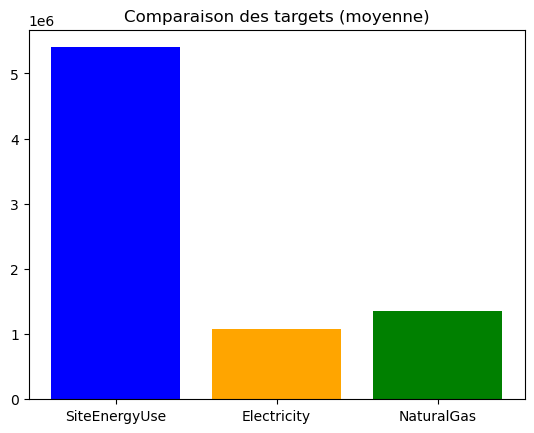

In [18]:
cols = ["SiteEnergyUse(kBtu)", "Electricity(kWh)", "NaturalGas(kBtu)"]

targets = ["SiteEnergyUse", "Electricity", "NaturalGas"]
means = [5.4e6, 1.08e6, 1.36e6]

plt.bar(targets, means, color=["blue", "orange", "green"])
plt.title("Comparaison des targets (moyenne)")
plt.show()

#### 2.Filtrage des types pertinents de bâtiments

In [19]:
consumption_df = pd.read_csv("data/2016_Building_Energy_Benchmarking_nettoyer.csv") #fichier nettoyer 

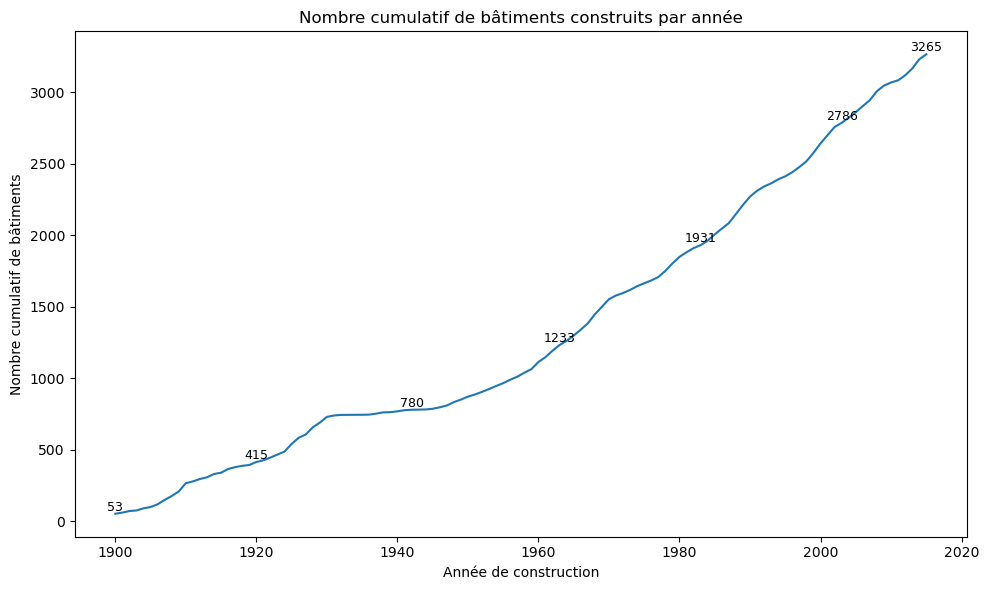

In [20]:
# Calculer le nombre cumulatif de bâtiments construits par année
buildings_per_year = consumption_df['YearBuilt'].value_counts().sort_index()
cumulative_buildings = buildings_per_year.cumsum()

plt.figure(figsize=(10,6))
sns.lineplot(x=cumulative_buildings.index.values, y=cumulative_buildings.values)
plt.xlabel("Année de construction")
plt.ylabel("Nombre cumulatif de bâtiments")
plt.title("Nombre cumulatif de bâtiments construits par année")

# Affichage des valeurs tous les 20 ans
for year in cumulative_buildings.index[::20]:
    value = cumulative_buildings.loc[year]
    plt.text(year, value, f"{value}", ha='center', va='bottom', fontsize=9, color='black')

# Affichage du chiffre à la dernière année si ce n'est pas déjà fait
last_year = cumulative_buildings.index[-1]
if last_year not in cumulative_buildings.index[::20]:
    value = cumulative_buildings.loc[last_year]
    plt.text(last_year, value, f"{value}", ha='center', va='bottom', fontsize=9, color='black')

plt.tight_layout()
plt.show()

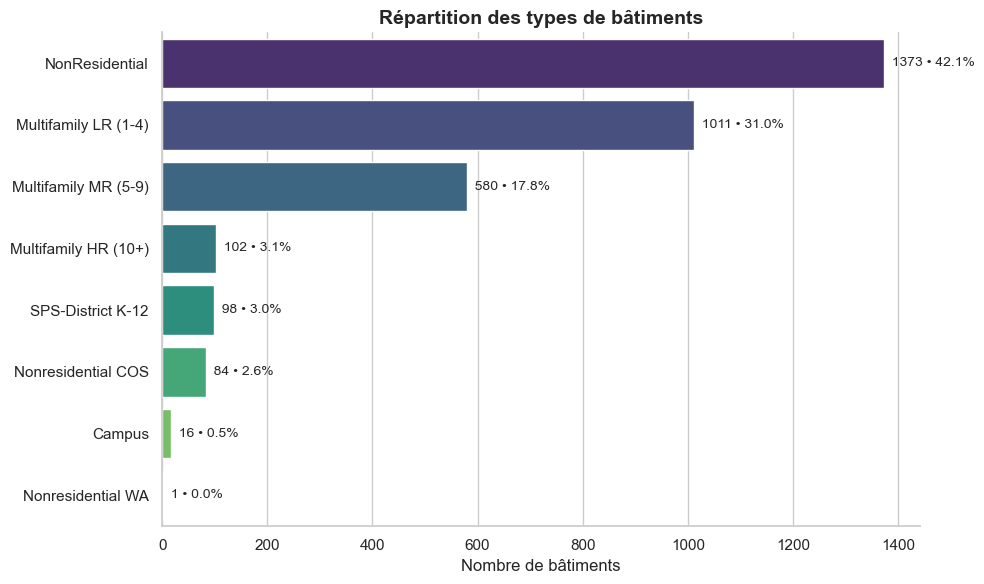

In [21]:
# Comptage du nombre de bâtiments par BuildingType
bt_counts = consumption_df['BuildingType'].value_counts().sort_values(ascending=False)
bt_percent = consumption_df['BuildingType'].value_counts(normalize=True).sort_values(ascending=False) * 100

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10,6))

# Barplot
ax = sns.barplot(
    x=bt_counts.values,
    y=bt_counts.index,
    hue=bt_counts.index,    # assigner hue à la variable catégorielle
    palette="viridis",
    dodge=False,
    legend=False             # pour ne pas afficher la légende
)

# Titre
plt.title("Répartition des types de bâtiments", fontsize=14, weight='bold')
plt.xlabel("Nombre de bâtiments")
plt.ylabel("")

# Annotations (nombre + %)
for i, (value, pct) in enumerate(zip(bt_counts.values, bt_percent.values)):
    ax.text(
        value,
        i,
        f"  {int(value)} • {pct:.1f}%",
        va='center',
        fontsize=10
    )

# Nettoyage
sns.despine()
plt.tight_layout()

plt.show()

In [22]:
consumption_df['BuildingType'].value_counts()

BuildingType
NonResidential          1373
Multifamily LR (1-4)    1011
Multifamily MR (5-9)     580
Multifamily HR (10+)     102
SPS-District K-12         98
Nonresidential COS        84
Campus                    16
Nonresidential WA          1
Name: count, dtype: int64

In [23]:
# Liste des batiments non residentiels
non_residentiel_type = [
    'NonResidential',
    'Nonresidential COS',
    'Nonresidential WA',
    'SPS-District K-12',
    'Campus'
]

# Liste des batiments résidentiels
residentiel_type = [
  'Multifamily LR (1-4)',
   'Multifamily MR (5-9)',
   'Multifamily HR (10+)'
]

#### Comparaison des types de batiments 

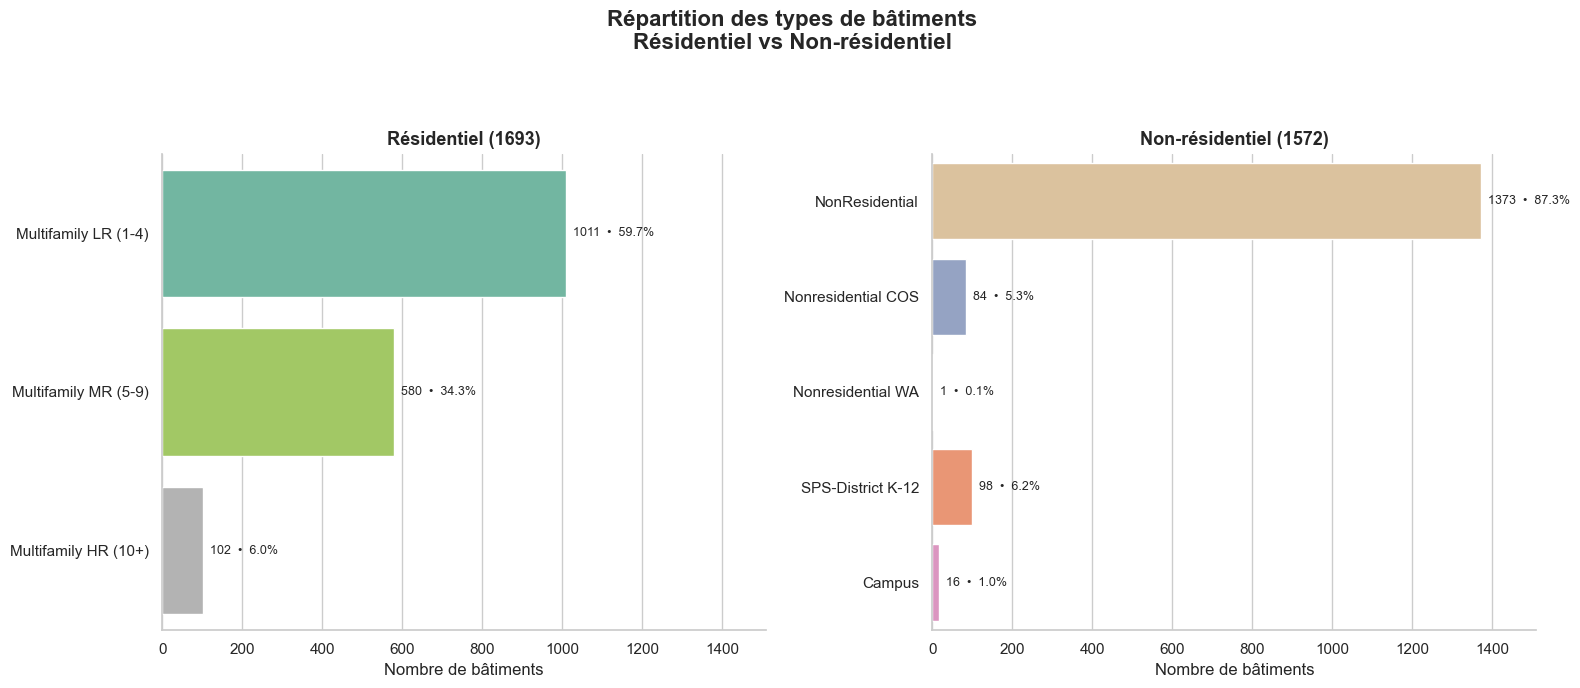

In [24]:
# -----------------------------
# 1. Préparation des données
# -----------------------------
r_type = residentiel_type
nr_type = non_residentiel_type

b_type = consumption_df['BuildingType'].value_counts()

res_vals = [int(b_type.get(t, 0)) for t in r_type]
nonres_vals = [int(b_type.get(t, 0)) for t in nr_type]

# Totaux
total_res = sum(res_vals)
total_nonres = sum(nonres_vals)

# -----------------------------
# 2. Couleurs cohérentes
# -----------------------------
sns.set_theme(style="whitegrid")

all_types = list(set(r_type + nr_type))
palette = sns.color_palette("Set2", len(all_types))
type_colors = dict(zip(all_types, palette))

colors_res = [type_colors.get(t, 'gray') for t in r_type]
colors_nonres = [type_colors.get(t, 'gray') for t in nr_type]

# -----------------------------
# 3. Figure
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ---------- Résidentiel ----------
ax = axes[0]
sns.barplot(
    x=res_vals,
    y=r_type,
    hue=r_type,
    palette=colors_res,
    legend=False,
    ax=ax
)

ax.set_title(f"Résidentiel ({total_res})", fontsize=13, weight='bold')
ax.set_xlabel("Nombre de bâtiments")
ax.set_ylabel("")
ax.spines[['top', 'right']].set_visible(False)

# Annotations
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    pct = (width / total_res * 100) if total_res > 0 else 0
    ax.text(width, y, f"  {int(width)}  •  {pct:.1f}%", va='center', fontsize=9)

# ---------- Non Résidentiel ----------
ax = axes[1]
sns.barplot(
    x=nonres_vals,
    y=nr_type,
    hue=nr_type,
    palette=colors_nonres,
    legend=False,
    ax=ax
)

ax.set_title(f"Non-résidentiel ({total_nonres})", fontsize=13, weight='bold')
ax.set_xlabel("Nombre de bâtiments")
ax.set_ylabel("")
ax.spines[['top', 'right']].set_visible(False)

# Annotations
for p in ax.patches:
    width = p.get_width()
    y = p.get_y() + p.get_height() / 2
    pct = (width / total_nonres * 100) if total_nonres > 0 else 0
    ax.text(width, y, f"  {int(width)}  •  {pct:.1f}%", va='center', fontsize=9)

# -----------------------------
# 4. Alignement des axes (important)
# -----------------------------
max_val = max(max(res_vals), max(nonres_vals)) if res_vals and nonres_vals else 1
axes[0].set_xlim(0, max_val * 1.1)
axes[1].set_xlim(0, max_val * 1.1)

# -----------------------------
# 5. Titre global
# -----------------------------
plt.suptitle(
    "Répartition des types de bâtiments\nRésidentiel vs Non-résidentiel",
    fontsize=16,
    weight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.92])
# -----------------------------
# 7. Affichage
# -----------------------------
plt.show()

##### 2.2. Filtrage des bâtiments non résidentiels

In [25]:
types_a_garder = [
    'NonResidential',
    'Nonresidential COS',
    'Nonresidential WA',
    'SPS-District K-12',
    'Campus'
]

# Création d’un DataFrame filtré
consumption_filtered = consumption_df[
    consumption_df['BuildingType'].isin(types_a_garder)
].copy()

# Vérification du nombre de lignes avant / après filtrage
print("Nombre de lignes avant filtrage :", consumption_df.shape[0])
print("Nombre de lignes après filtrage :", consumption_filtered.shape[0])

Nombre de lignes avant filtrage : 3265
Nombre de lignes après filtrage : 1572


In [26]:
consumption_filtered.to_csv("data/2016_Building_Energy_Benchmarking_filtrer.csv") #fichier filtrer 

#### 3 Compréhension et sélection des colonnes

##### Choix de la variable cible

Le dataset contient plusieurs variables susceptibles de servir de cible pour un modèle prédictif, notamment :

**SiteEnergyUse(kBtu)**

**Electricity(kWh)**

**NaturalGas(kBtu)**

Pour ce projet, la variable cible retenue est **SiteEnergyUse(kBtu)**.

Ce choix repose sur plusieurs éléments :

Consommation totale : c’est la seule variable qui représente la consommation énergétique globale du bâtiment, toutes énergies confondues.

Lien direct avec les caractéristiques du bâtiment : elle dépend fortement de la surface, du type de bâtiment, du nombre d’étages, de l’année de construction, etc., ce qui en fait une cible cohérente pour un modèle supervisé.

Stabilité et pertinence : contrairement aux émissions de CO₂, elle n’est pas influencée par le mix énergétique local ou les facteurs externes.

Variable de référence : elle constitue une base solide pour estimer ensuite d’autres indicateurs comme les émissions de gaz à effet de serre.

Ainsi, **SiteEnergyUse(kBtu)** est la variable la plus pertinente pour modéliser la performance énergétique des bâtiments, en particulier dans le cadre de ce projet.

# Modélisation 

In [27]:
consumption_df = pd.read_csv("data/2016_Building_Energy_Benchmarking_filtrer.csv")

### Import des modules 

In [28]:
#Selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV, 
    cross_validate,
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error 
from sklearn.inspection import permutation_importance

#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

#Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression


## feature Engineering

A réaliser : Enrichir le jeu de données actuel avec de nouvelles features issues de celles existantes. 

In [29]:
consumption_df.head()

,Unnamed: 0,OSEBuildingID,DataYear,BuildingType,PrimaryPropertyType,PropertyName,Address,City,State,ZipCode,...,SiteEnergyUseWN(kBtu),SteamUse(kBtu),Electricity(kWh),Electricity(kBtu),NaturalGas(therms),NaturalGas(kBtu),DefaultData,ComplianceStatus,TotalGHGEmissions,GHGEmissionsIntensity
0,0,1,2016,NonResidential,Hotel,Mayflower park hotel,405 Olive way,Seattle,WA,98101.0,...,7456910.0,2003882.00,1.156514e+06,3946027.0,12764.52930,1276453.0,False,Compliant,249.98,2.83
1,1,2,2016,NonResidential,Hotel,Paramount Hotel,724 Pine street,Seattle,WA,98101.0,...,8664479.0,0.00,9.504252e+05,3242851.0,51450.81641,5145082.0,False,Compliant,295.86,2.86
2,2,5,2016,NonResidential,Hotel,HOTEL MAX,620 STEWART ST,Seattle,WA,98101.0,...,6946800.5,2214446.25,8.115253e+05,2768924.0,18112.13086,1811213.0,False,Compliant,286.43,4.67
3,3,8,2016,NonResidential,Hotel,WARWICK SEATTLE HOTEL (ID8),401 LENORA ST,Seattle,WA,98121.0,...,14656503.0,0.00,1.573449e+06,5368607.0,88039.98438,8803998.0,False,Compliant,505.01,2.88
4,4,9,2016,Nonresidential COS,Other,West Precinct,810 Virginia St,Seattle,WA,98101.0,...,12581712.0,0.00,2.160444e+06,7371434.0,47151.81641,4715182.0,False,Compliant,301.81,3.10


### *batiment*

In [30]:
consumption_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1572 entries, 0 to 1571
Data columns (total 42 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Unnamed: 0                       1572 non-null   int64  
 1   OSEBuildingID                    1572 non-null   int64  
 2   DataYear                         1572 non-null   int64  
 3   BuildingType                     1572 non-null   object 
 4   PrimaryPropertyType              1572 non-null   object 
 5   PropertyName                     1572 non-null   object 
 6   Address                          1572 non-null   object 
 7   City                             1572 non-null   object 
 8   State                            1572 non-null   object 
 9   ZipCode                          1556 non-null   float64
 10  TaxParcelIdentificationNumber    1572 non-null   object 
 11  CouncilDistrictCode              1572 non-null   int64  
 12  Neighborhood        

#### Type BATIMENT 

In [31]:
df_type= consumption_df[[
     "PrimaryPropertyType",
]].copy()

In [32]:
category = {
    # Office
    "Small- and Mid-Sized Office": "Office",
    "Large Office": "Office",
    "Medical Office": "Office",
    "Office": "Office",

    # Education
    "K-12 School": "Education",
    "University": "Education",

    # Retail & Food
    "Retail Store": "Retail & Food",
    "Supermarket / Grocery Store": "Retail & Food",
    "Restaurant": "Retail & Food",

    # Industrial & Storage
    "Warehouse": "Industrial & Storage",
    "Distribution Center": "Industrial & Storage",
    "Refrigerated Warehouse": "Industrial & Storage",
    "Self-Storage Facility": "Industrial & Storage",
    "Laboratory": "Industrial & Storage",

    # Hospitality
    "Hotel": "Hospitality",

    # Healthcare
    "Hospital": "Healthcare",

    # Public / Institutional
    "Worship Facility": "Public / Institutional",

    # Mixed Use
    "Mixed Use Property": "Mixed Use",

    # Autres
    "Other": "Other",

    # Catégorie à exclure
    "Low-rise Multifamily": "Delete",
    "Residence Hall": "Delete",
    "Senior Care Community": "Delete"

}

In [33]:
def create_type_features(df_type):
    # Créer la nouvelle colonne avec regroupement
    df_type["PropertyCategory"] = df_type["PrimaryPropertyType"].map(category).fillna("Other")

    # Supprimer les lignes à exclure
    df_type = df_type[df_type["PropertyCategory"] != "Delete"]

    # Vérifier la distribution
    print(df_type["PropertyCategory"].value_counts())

    return df_type

In [34]:
df_type_feature = create_type_features(df_type)

PropertyCategory
Office                    475
Industrial & Storage      285
Other                     238
Education                 156
Retail & Food             140
Mixed Use                 101
Public / Institutional     71
Hospitality                69
Healthcare                  1
Name: count, dtype: int64


In [35]:
df_type_feature.head()

,PrimaryPropertyType,PropertyCategory
0,Hotel,Hospitality
1,Hotel,Hospitality
2,Hotel,Hospitality
3,Hotel,Hospitality
4,Other,Other


#### Age BATIMENT 

In [36]:
df_age = consumption_df[[
    "DataYear",
    "YearBuilt",
]].copy()

In [37]:
def create_age_features(df_age):
    df_age = df_age.copy()
    
    # Age brut
    df_age["BuildingAge"] = df_age["DataYear"] - df_age["YearBuilt"]
        
    return df_age

In [38]:
df_age_feature = create_age_features(df_age)

In [39]:
df_age_feature.head()

,DataYear,YearBuilt,BuildingAge
0,2016,1927,89
1,2016,1996,20
2,2016,1926,90
3,2016,1980,36
4,2016,1999,17


In [40]:
df_age_feature.notna().mean()

DataYear       1.0
YearBuilt      1.0
BuildingAge    1.0
dtype: float64

#### Surface et usage

In [41]:
df_surface = consumption_df[[
    "PropertyGFATotal",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA",
    "NumberofFloors",
]].copy()


In [42]:
def create_surface_features(df_surface):
    df_surface = df_surface.copy()
    
    df_surface["ratio_floors"]=(
        df_surface["PropertyGFATotal"] / df_surface["NumberofFloors"]
    )
    
    df_surface["ratio_largest_use"] = (
        df_surface["LargestPropertyUseTypeGFA"] / df_surface["PropertyGFATotal"]
    )

    df_surface["ratio_second_use"] = (
        df_surface["SecondLargestPropertyUseTypeGFA"] / df_surface["PropertyGFATotal"]
    )
    df_surface["ratio_two_largest"] = (
    df_surface["LargestPropertyUseTypeGFA"].fillna(0) +
    df_surface["SecondLargestPropertyUseTypeGFA"].fillna(0)
) / df_surface["PropertyGFATotal"]

        # Remplacer les NaN par 0
    df_surface = df_surface.fillna(0)
    return df_surface

In [43]:
df_surface_feature = create_surface_features(df_surface)

In [44]:
df_surface_feature.head()

,PropertyGFATotal,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,NumberofFloors,ratio_floors,ratio_largest_use,ratio_second_use,ratio_two_largest
0,88434,88434.0,0.0,12,7369.500000,1.000000,0.000000,1.000000
1,103566,83880.0,15064.0,11,9415.090909,0.809918,0.145453,0.955371
2,61320,61320.0,0.0,10,6132.000000,1.000000,0.000000,1.000000
3,175580,123445.0,68009.0,18,9754.444444,0.703070,0.387339,1.090409
4,97288,88830.0,0.0,2,48644.000000,0.913062,0.000000,0.913062


In [45]:
df_surface_feature.notna().mean()

PropertyGFATotal                   1.0
LargestPropertyUseTypeGFA          1.0
SecondLargestPropertyUseTypeGFA    1.0
NumberofFloors                     1.0
ratio_floors                       1.0
ratio_largest_use                  1.0
ratio_second_use                   1.0
ratio_two_largest                  1.0
dtype: float64

#### Localisation

In [46]:
df_localisation = consumption_df[[
    "Latitude",
    "Longitude",
    "ZipCode",
    "Neighborhood", 
    "City",
    "State"
]].copy()

# Convertir ZipCode en string pour éviter les erreurs
df_localisation["ZipCode"] = df_localisation["ZipCode"].astype(str)

In [47]:
def create_localisation_features(df_localisation):
    df_localisation = df_localisation.copy()

    # Nettoyage
    for col in ["City", "State", "Neighborhood"]:
        df_localisation[col] =df_localisation[col].fillna("Unknown").str.strip()

    # Features catégorielles
    df_localisation["lieux_fins"] = df_localisation["ZipCode"].astype(str) + "_" + df_localisation["Neighborhood"]
    df_localisation["lieux_moyens"] = df_localisation["City"] + "_" + df_localisation["State"]

    # Distance Haversine
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat, dlon = lat2 - lat1, lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
        return 2 * R * np.arcsin(np.sqrt(a))

    center_lat, center_lon =df_localisation["Latitude"].mean(), df_localisation["Longitude"].mean()

    df_localisation["distance_center"] = haversine(
        df_localisation["Latitude"], df_localisation["Longitude"], center_lat, center_lon
    ).fillna(lambda x: x.mean())

    return df_localisation


In [48]:
df_localisation_features = create_localisation_features(df_localisation)

In [49]:
df_localisation_features.head()

,Latitude,Longitude,ZipCode,Neighborhood,City,State,lieux_fins,lieux_moyens,distance_center
0,47.61220,-122.33799,98101.0,DOWNTOWN,Seattle,WA,98101.0_DOWNTOWN,Seattle_WA,0.561227
1,47.61317,-122.33393,98101.0,DOWNTOWN,Seattle,WA,98101.0_DOWNTOWN,Seattle_WA,0.320116
2,47.61412,-122.33664,98101.0,DOWNTOWN,Seattle,WA,98101.0_DOWNTOWN,Seattle_WA,0.340497
3,47.61375,-122.34047,98121.0,DOWNTOWN,Seattle,WA,98121.0_DOWNTOWN,Seattle_WA,0.610053
4,47.61623,-122.33657,98101.0,DOWNTOWN,Seattle,WA,98101.0_DOWNTOWN,Seattle_WA,0.266175


In [50]:
df_localisation_features.notna().mean()

Latitude           1.0
Longitude          1.0
ZipCode            1.0
Neighborhood       1.0
City               1.0
State              1.0
lieux_fins         1.0
lieux_moyens       1.0
distance_center    1.0
dtype: float64

#### Energy

In [51]:
df_energy = consumption_df[[
    "NaturalGas(kBtu)",
    "Electricity(kBtu)",
    "SteamUse(kBtu)"
]].copy()

In [52]:
def create_energy_features(df_energy):
    df_energy = df_energy.copy()

    # présence des sources (safe)
    df_energy["use_gas"] = (df_energy["NaturalGas(kBtu)"] > 0).astype(int)
    df_energy["use_electricity"] = (df_energy["Electricity(kBtu)"] > 0).astype(int)
    df_energy["use_steam"] = (df_energy["SteamUse(kBtu)"] > 0).astype(int)
    
    # nombre de sources
    df_energy["nb_energy_sources"] = df_energy[
        ["use_gas", "use_electricity", "use_steam"]
    ].sum(axis=1)

    # d’identifier les bâtiments multi-énergie
    df_energy["is_multi_energy"] = (df_energy["nb_energy_sources"] > 1).astype(int)
    
    return df_energy

In [53]:
df_energy_features  = create_energy_features(df_energy)

In [54]:
df_energy_features.head()

,NaturalGas(kBtu),Electricity(kBtu),SteamUse(kBtu),use_gas,use_electricity,use_steam,nb_energy_sources,is_multi_energy
0,1276453.0,3946027.0,2003882.00,1,1,1,3,1
1,5145082.0,3242851.0,0.00,1,1,0,2,1
2,1811213.0,2768924.0,2214446.25,1,1,1,3,1
3,8803998.0,5368607.0,0.00,1,1,0,2,1
4,4715182.0,7371434.0,0.00,1,1,0,2,1


#### Fusion 

In [55]:
# 1. Fusionner les features finales
df_features = pd.concat([
    df_type_feature[['PropertyCategory']],
    df_age_feature[['BuildingAge']],
    df_surface_feature[['NumberofFloors', "PropertyGFATotal",
    "LargestPropertyUseTypeGFA",
    "SecondLargestPropertyUseTypeGFA","ratio_floors","ratio_largest_use","ratio_second_use","ratio_two_largest",]],
    df_localisation_features[['Latitude','Longitude','distance_center']], 
    df_energy_features[['nb_energy_sources']]
], axis=1)

# 2. Définir la target
target = "SiteEnergyUse(kBtu)"

# 3. Construire X et y
X = df_features
y = consumption_df[target]

X.to_csv("data/X_features.csv", index=True)
y.to_csv("data/y_target.csv", index=True)

df_features = X.copy()
df_features[target] = y

df_features.to_csv("data/2016_Building_feacture.csv", index=True)


In [56]:
df_features.head()

,PropertyCategory,BuildingAge,NumberofFloors,PropertyGFATotal,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ratio_floors,ratio_largest_use,ratio_second_use,ratio_two_largest,Latitude,Longitude,distance_center,nb_energy_sources,SiteEnergyUse(kBtu)
0,Hospitality,89,12,88434,88434.0,0.0,7369.500000,1.000000,0.000000,1.000000,47.61220,-122.33799,0.561227,3,7226362.5
1,Hospitality,20,11,103566,83880.0,15064.0,9415.090909,0.809918,0.145453,0.955371,47.61317,-122.33393,0.320116,2,8387933.0
2,Hospitality,90,10,61320,61320.0,0.0,6132.000000,1.000000,0.000000,1.000000,47.61412,-122.33664,0.340497,3,6794584.0
3,Hospitality,36,18,175580,123445.0,68009.0,9754.444444,0.703070,0.387339,1.090409,47.61375,-122.34047,0.610053,2,14172606.0
4,Other,17,2,97288,88830.0,0.0,48644.000000,0.913062,0.000000,0.913062,47.61623,-122.33657,0.266175,2,12086616.0


In [57]:
def one_hot_property_category(input_path, output_path=None):
    df_features = pd.read_csv(input_path, index_col=0)

    if "PropertyCategory" not in df_features.columns:
        raise ValueError("La colonne 'PropertyCategory' est introuvable.")

    # One-Hot Encoding optimisé
    ohe = pd.get_dummies(
        df_features["PropertyCategory"],
        prefix="Category",
        drop_first=True
    ).astype(np.int8)

    # Supprimer la colonne originale + concat
    df_encoded = pd.concat(
        [df_features.drop(columns=["PropertyCategory"]), ohe],
        axis=1
    )

    if output_path:
        df_encoded.to_csv(output_path, index=True)

    print(df_encoded.head())

    return df_encoded

In [58]:
df_encoded = one_hot_property_category("data/2016_Building_feacture.csv")

   BuildingAge  NumberofFloors  PropertyGFATotal  LargestPropertyUseTypeGFA  \
0           89              12             88434                    88434.0   
1           20              11            103566                    83880.0   
2           90              10             61320                    61320.0   
3           36              18            175580                   123445.0   
4           17               2             97288                    88830.0   

   SecondLargestPropertyUseTypeGFA  ratio_floors  ratio_largest_use  \
0                              0.0   7369.500000           1.000000   
1                          15064.0   9415.090909           0.809918   
2                              0.0   6132.000000           1.000000   
3                          68009.0   9754.444444           0.703070   
4                              0.0  48644.000000           0.913062   

   ratio_second_use  ratio_two_largest  Latitude  ...  nb_energy_sources  \
0          0.000000   

In [59]:
df_encoded.head()

,BuildingAge,NumberofFloors,PropertyGFATotal,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ratio_floors,ratio_largest_use,ratio_second_use,ratio_two_largest,Latitude,...,nb_energy_sources,SiteEnergyUse(kBtu),Category_Healthcare,Category_Hospitality,Category_Industrial & Storage,Category_Mixed Use,Category_Office,Category_Other,Category_Public / Institutional,Category_Retail & Food
0,89,12,88434,88434.0,0.0,7369.500000,1.000000,0.000000,1.000000,47.61220,...,3,7226362.5,0,1,0,0,0,0,0,0
1,20,11,103566,83880.0,15064.0,9415.090909,0.809918,0.145453,0.955371,47.61317,...,2,8387933.0,0,1,0,0,0,0,0,0
2,90,10,61320,61320.0,0.0,6132.000000,1.000000,0.000000,1.000000,47.61412,...,3,6794584.0,0,1,0,0,0,0,0,0
3,36,18,175580,123445.0,68009.0,9754.444444,0.703070,0.387339,1.090409,47.61375,...,2,14172606.0,0,1,0,0,0,0,0,0
4,17,2,97288,88830.0,0.0,48644.000000,0.913062,0.000000,0.913062,47.61623,...,2,12086616.0,0,0,0,0,0,1,0,0


# Préparation des features pour la modélisation

A réaliser :
* Si ce n'est pas déjà fait, supprimer toutes les colonnes peu pertinentes pour la modélisation.
* Tracer la distribution de la cible pour vous familiariser avec l'ordre de grandeur. En cas d'outliers, mettez en place une démarche pour les supprimer.
* Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.
* Réalisez différents graphiques pour comprendre le lien entre vos features et la target (boxplots, scatterplots, pairplot si votre nombre de features numériques n'est pas très élevé).
*  Séparez votre jeu de données en un Pandas DataFrame X (ensemble de feautures) et Pandas Series y (votre target).
* Si vous avez des features catégorielles, il faut les encoder pour que votre modèle fonctionne.

#### supprimer toutes les colonnes peu pertinentes pour la modélisation

In [60]:
df_encoded = pd.read_csv("data/2016_Building_feacture.csv")

In [61]:
df_encoded.head()

,Unnamed: 0,PropertyCategory,BuildingAge,NumberofFloors,PropertyGFATotal,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ratio_floors,ratio_largest_use,ratio_second_use,ratio_two_largest,Latitude,Longitude,distance_center,nb_energy_sources,SiteEnergyUse(kBtu)
0,0,Hospitality,89,12,88434,88434.0,0.0,7369.500000,1.000000,0.000000,1.000000,47.61220,-122.33799,0.561227,3,7226362.5
1,1,Hospitality,20,11,103566,83880.0,15064.0,9415.090909,0.809918,0.145453,0.955371,47.61317,-122.33393,0.320116,2,8387933.0
2,2,Hospitality,90,10,61320,61320.0,0.0,6132.000000,1.000000,0.000000,1.000000,47.61412,-122.33664,0.340497,3,6794584.0
3,3,Hospitality,36,18,175580,123445.0,68009.0,9754.444444,0.703070,0.387339,1.090409,47.61375,-122.34047,0.610053,2,14172606.0
4,4,Other,17,2,97288,88830.0,0.0,48644.000000,0.913062,0.000000,0.913062,47.61623,-122.33657,0.266175,2,12086616.0


In [62]:
df_encoded.columns

Index(['Unnamed: 0', 'PropertyCategory', 'BuildingAge', 'NumberofFloors',
       'PropertyGFATotal', 'LargestPropertyUseTypeGFA',
       'SecondLargestPropertyUseTypeGFA', 'ratio_floors', 'ratio_largest_use',
       'ratio_second_use', 'ratio_two_largest', 'Latitude', 'Longitude',
       'distance_center', 'nb_energy_sources', 'SiteEnergyUse(kBtu)'],
      dtype='object')

In [63]:
df_encoded = df_encoded.drop(columns=[
    'Unnamed: 0',
    'Latitude',
    'Longitude'
])

In [64]:
X = df_encoded.drop(columns=['SiteEnergyUse(kBtu)'])
y = df_encoded['SiteEnergyUse(kBtu)']
# Sauvegarde
X.to_csv("data/X_nettoyer.csv", index=False)

In [65]:
X.head()

,PropertyCategory,BuildingAge,NumberofFloors,PropertyGFATotal,LargestPropertyUseTypeGFA,SecondLargestPropertyUseTypeGFA,ratio_floors,ratio_largest_use,ratio_second_use,ratio_two_largest,distance_center,nb_energy_sources
0,Hospitality,89,12,88434,88434.0,0.0,7369.500000,1.000000,0.000000,1.000000,0.561227,3
1,Hospitality,20,11,103566,83880.0,15064.0,9415.090909,0.809918,0.145453,0.955371,0.320116,2
2,Hospitality,90,10,61320,61320.0,0.0,6132.000000,1.000000,0.000000,1.000000,0.340497,3
3,Hospitality,36,18,175580,123445.0,68009.0,9754.444444,0.703070,0.387339,1.090409,0.610053,2
4,Other,17,2,97288,88830.0,0.0,48644.000000,0.913062,0.000000,0.913062,0.266175,2


In [66]:
y.head()

0     7226362.5
1     8387933.0
2     6794584.0
3    14172606.0
4    12086616.0
Name: SiteEnergyUse(kBtu), dtype: float64

#### Tracer la distribution de la cible 

In [67]:
X.columns

Index(['PropertyCategory', 'BuildingAge', 'NumberofFloors', 'PropertyGFATotal',
       'LargestPropertyUseTypeGFA', 'SecondLargestPropertyUseTypeGFA',
       'ratio_floors', 'ratio_largest_use', 'ratio_second_use',
       'ratio_two_largest', 'distance_center', 'nb_energy_sources'],
      dtype='object')

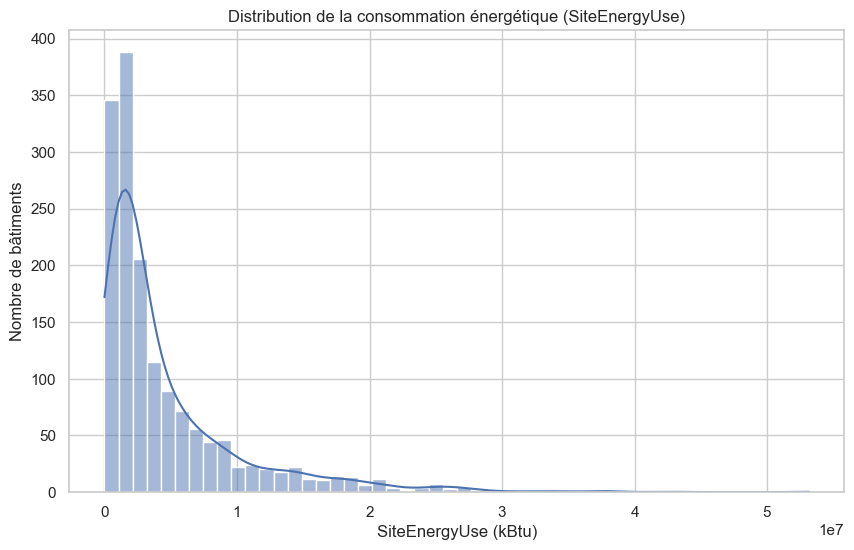

In [68]:
# Tracer l'histogramme de la target
plt.figure(figsize=(10,6))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution de la consommation énergétique (SiteEnergyUse)")
plt.xlabel("SiteEnergyUse (kBtu)")
plt.ylabel("Nombre de bâtiments")
plt.show()

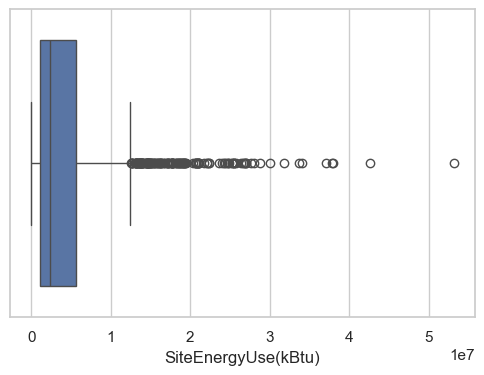

In [69]:
plt.figure(figsize=(6,4))
sns.boxplot(x=y)
plt.show()

In [70]:
# Réalignement strict des index
X, y = X.align(y, join="inner", axis=0)

# Calcul des quantiles aux 1% et 99%
lower_quantile = y.quantile(0.01)
upper_quantile = y.quantile(0.99)

# Filtrer les données pour garder uniquement celles entre ces quantiles
mask = (y >= lower_quantile) & (y <= upper_quantile)
X = X[mask].copy()
y = y[mask].copy()

print(f"Taille initiale : {len(y)}")
print(f"Taille après filtrage quantile 1%-99% : {len(y)}")

Taille initiale : 1540
Taille après filtrage quantile 1%-99% : 1540


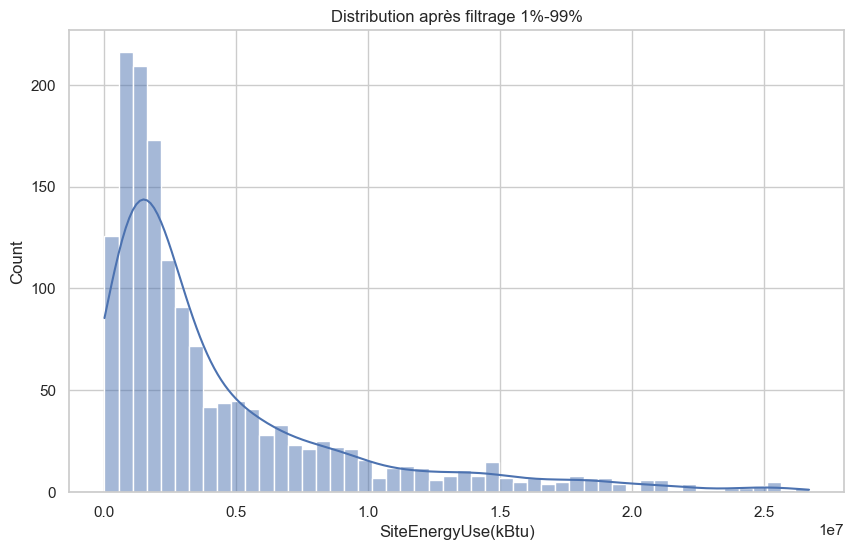

In [71]:
plt.figure(figsize=(10,6))
sns.histplot(y, bins=50, kde=True)
plt.title("Distribution après filtrage 1%-99%")
plt.show()

In [72]:
X_filtrage = X
y_filtrage = y

X_filtrage.to_csv("data/X_2016_no_outliers.csv", index=False)
y_filtrage.to_csv("data/y_2016_no_outliers.csv", index=False)

#### Débarrassez-vous des features redondantes en utilisant une matrice de corrélation.

In [73]:
# Garder uniquement les variables numériques
X_num = X_filtrage.select_dtypes(include=["int64", "float64"])
# Supprimer les colonnes constantes (variance=0)
X_num = X_num.loc[:, X_num.nunique() > 1]

# Matrice de corrélation
corr_matrix = X_num.corr()

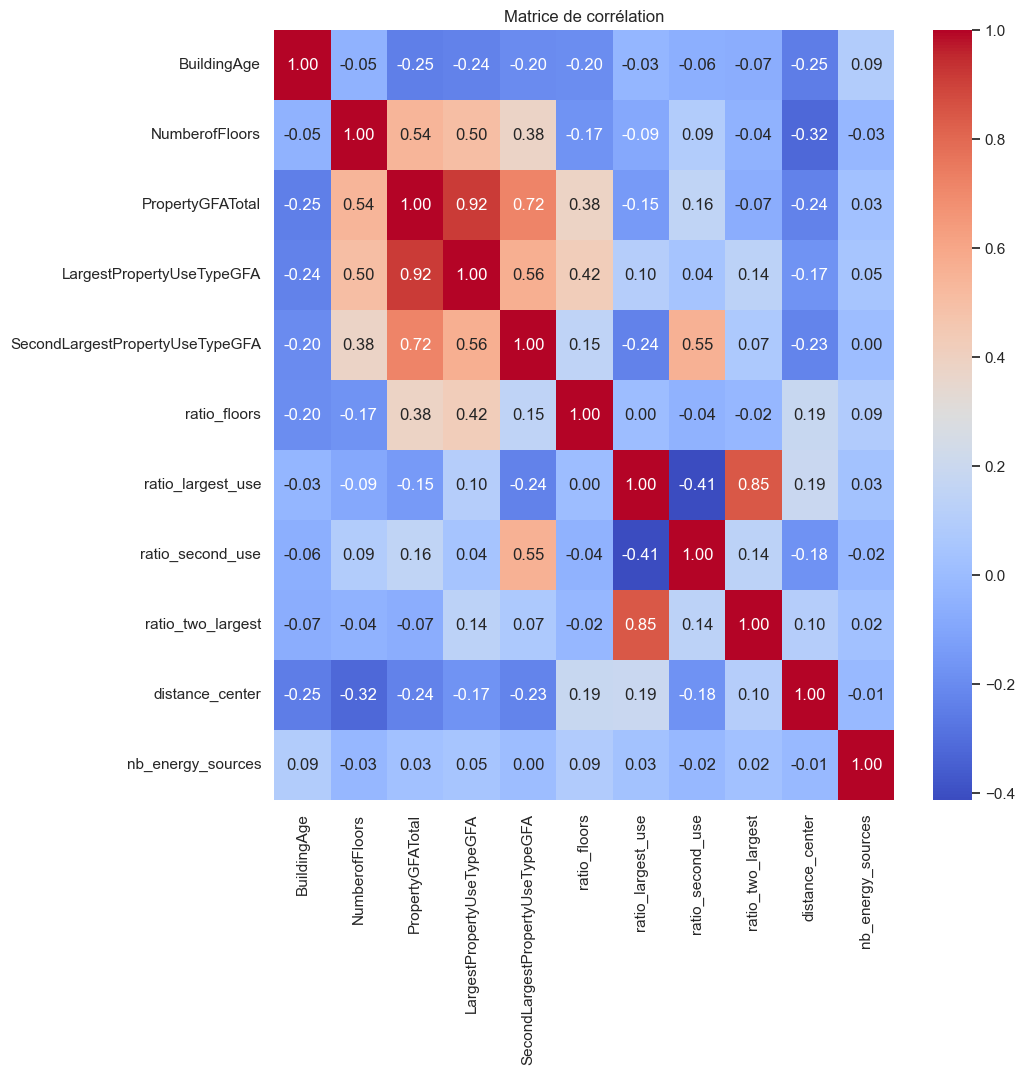

In [74]:
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Matrice de corrélation")
plt.show()

In [75]:
# Seuil de corrélation
threshold = 0.9

# Matrice triangulaire supérieure
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Colonnes à supprimer
to_drop = [column for column in upper.columns if any(upper[column] > threshold)]

print("Colonnes à supprimer :", to_drop)

Colonnes à supprimer : ['LargestPropertyUseTypeGFA']


In [76]:
x_reduced = X_filtrage.drop(columns=to_drop)

In [77]:
x_reduced.to_csv("data/X_2016_seuil_corrélation.csv", index=False)

#### Réalisez différents graphiques pour comprendre le lien entre vos features et la target

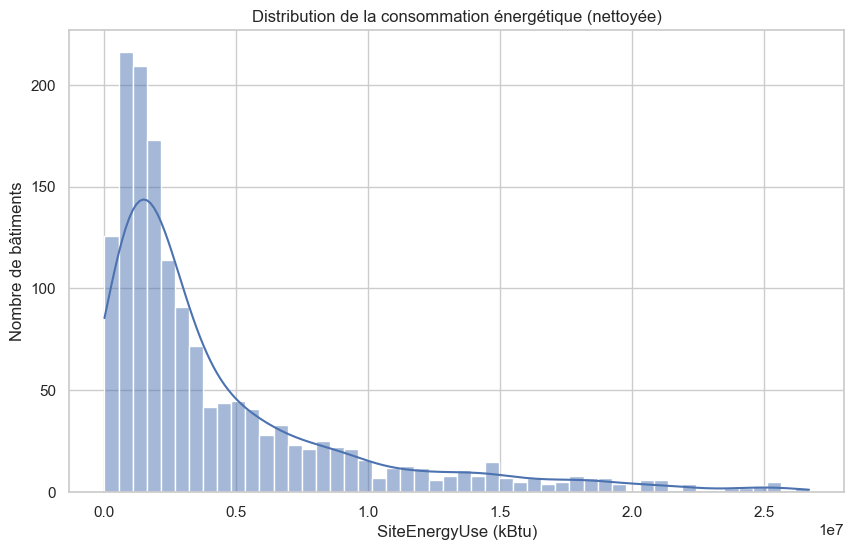

In [78]:
plt.figure(figsize=(10,6))
sns.histplot(y_filtrage, bins=50, kde=True)
plt.title("Distribution de la consommation énergétique (nettoyée)")
plt.xlabel("SiteEnergyUse (kBtu)")
plt.ylabel("Nombre de bâtiments")
plt.show()

Réalisez différents graphiques pour comprendre le lien entre vos features et la target

In [79]:
# Variables numériques
num_cols = x_reduced.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Variables catégorielles
cat_cols = x_reduced.select_dtypes(include=['object', 'category']).columns.tolist()

print("Variables numériques :", num_cols)
print("Variables catégorielles :", cat_cols)

Variables numériques : ['BuildingAge', 'NumberofFloors', 'PropertyGFATotal', 'SecondLargestPropertyUseTypeGFA', 'ratio_floors', 'ratio_largest_use', 'ratio_second_use', 'ratio_two_largest', 'distance_center', 'nb_energy_sources']
Variables catégorielles : ['PropertyCategory']


In [80]:
# Concaténer X et y pour pouvoir calculer la corrélation
df_corr = x_reduced.copy()
df_corr["target"] = y_filtrage  # ajoute la target

# Calculer la corrélation
corr = df_corr.corr(numeric_only=True)

# Trier par corrélation avec la target
print(corr["target"].sort_values(ascending=False))

target                             1.000000
PropertyGFATotal                   0.734032
SecondLargestPropertyUseTypeGFA    0.481409
NumberofFloors                     0.426569
ratio_floors                       0.313413
nb_energy_sources                  0.143255
ratio_second_use                   0.121255
ratio_two_largest                 -0.010890
ratio_largest_use                 -0.075457
distance_center                   -0.221625
BuildingAge                       -0.232205
Name: target, dtype: float64


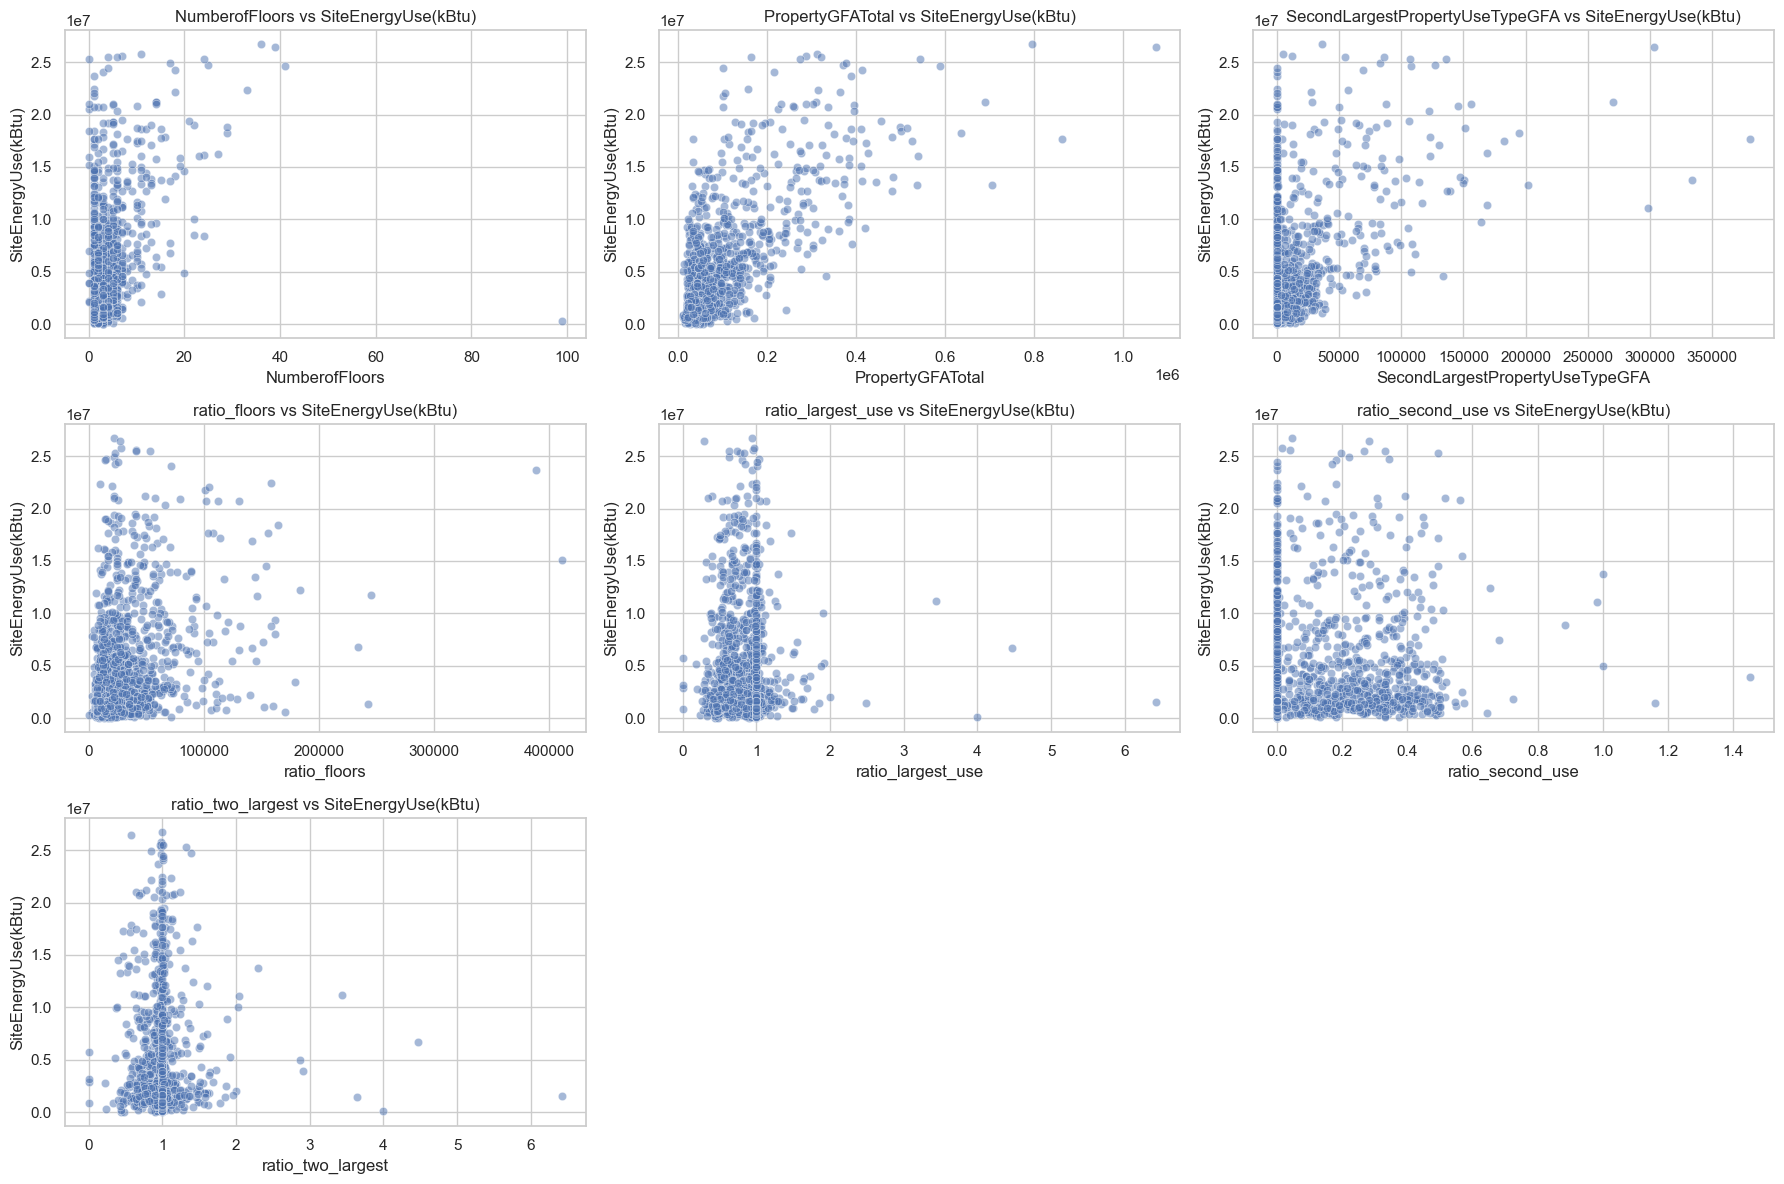

In [81]:
selected_cols = ['NumberofFloors', 'PropertyGFATotal', 'SecondLargestPropertyUseTypeGFA', 'ratio_floors', 'ratio_largest_use', 'ratio_second_use', 'ratio_two_largest'] 

n = len(selected_cols)

cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(selected_cols, 1):
    plt.subplot(rows, cols, i)
    sns.scatterplot(x=x_reduced[col], y=y_filtrage, alpha=0.5)  
    plt.title(f"{col} vs {target}")
    plt.tight_layout()

plt.show()

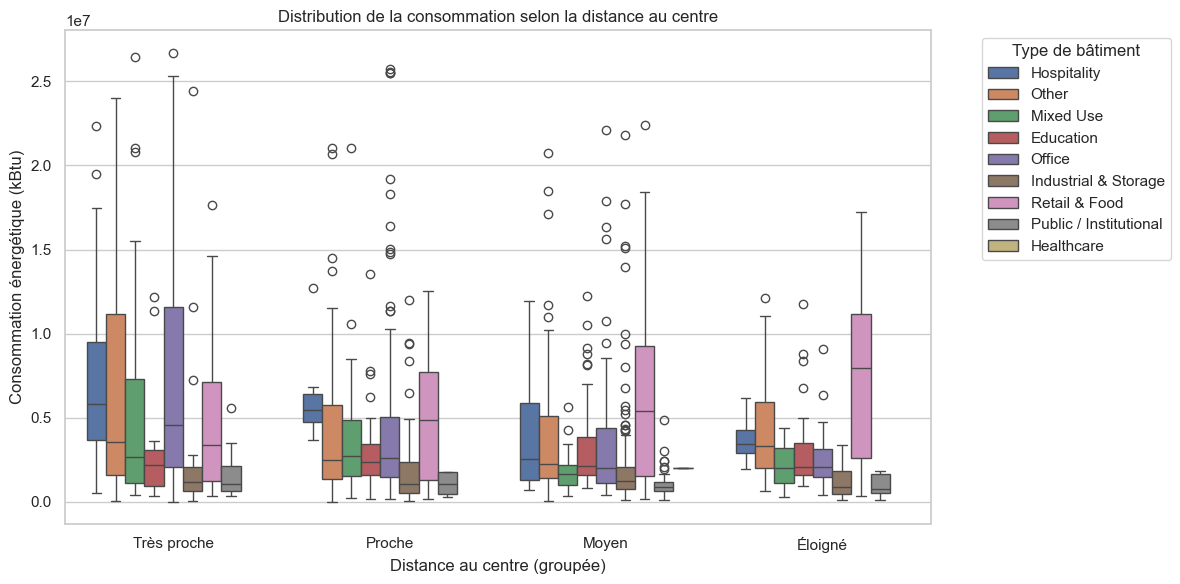

In [82]:
# 1. Création des groupes de distance
max_dist = x_reduced["distance_center"].max()

bins = [0, 2, 5, 10, max_dist]
labels = ["Très proche", "Proche", "Moyen", "Éloigné"]

x_reduced["distance_group"] = pd.cut(
    x_reduced["distance_center"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# 2. Fusion X + y pour faciliter les graphiques
df_plot = x_reduced.copy()
df_plot["target"] = y_filtrage

# 3. Boxplot distance_group × target × PropertyCategory
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_plot,
    x="distance_group",
    y="target",
    hue="PropertyCategory"
)

plt.title("Distribution de la consommation selon la distance au centre")
plt.xlabel("Distance au centre (groupée)")
plt.ylabel("Consommation énergétique (kBtu)")
plt.legend(title="Type de bâtiment", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


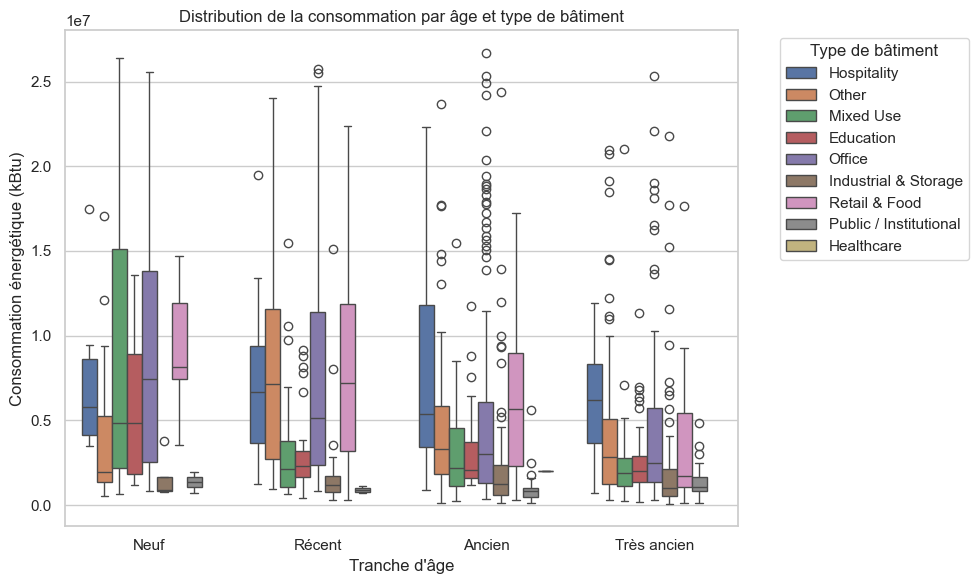

In [83]:
# --- 1. Création des groupes d'âge ---
bins = [0, 10, 30, 60, 100]
labels = ["Neuf", "Récent", "Ancien", "Très ancien"]

x_reduced["age_group"] = pd.cut(
    x_reduced["BuildingAge"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# --- 2. Fusion X + y ---
df_plot = x_reduced.copy()
df_plot["target"] = y_filtrage

# --- 3. Boxplot ---
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_plot,
    x="age_group",
    y="target",
    hue="PropertyCategory"
)

plt.title("Distribution de la consommation par âge et type de bâtiment")
plt.xlabel("Tranche d'âge")
plt.ylabel("Consommation énergétique (kBtu)")
plt.legend(title="Type de bâtiment", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()


In [84]:
cat_cols = x_reduced.select_dtypes(include=["object", "category"]).columns
print("Variables catégorielles :", list(cat_cols))

Variables catégorielles : ['PropertyCategory', 'distance_group', 'age_group']


In [85]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identification des colonnes
num_cols = x_reduced.select_dtypes(include=["int64", "float64"]).columns
cat_cols = x_reduced.select_dtypes(include=["object", "category"]).columns

print("Numériques :", list(num_cols))
print("Catégorielles :", list(cat_cols))

# Préprocesseur pour la modélisation
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

print("Encodage OneHotEncoder prêt pour les variables catégorielles.")


Numériques : ['BuildingAge', 'NumberofFloors', 'PropertyGFATotal', 'SecondLargestPropertyUseTypeGFA', 'ratio_floors', 'ratio_largest_use', 'ratio_second_use', 'ratio_two_largest', 'distance_center', 'nb_energy_sources']
Catégorielles : ['PropertyCategory', 'distance_group', 'age_group']
Encodage OneHotEncoder prêt pour les variables catégorielles.


# Comparaison de différents modèles supervisés

A réaliser :
* Pour chaque algorithme que vous allez tester, vous devez :
    * Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.
    * Si les features quantitatives que vous souhaitez utiliser ont des ordres de grandeur très différents les uns des autres, et que vous utilisez un algorithme de regression qui est sensible à cette différence, alors il faut réaliser un scaling (normalisation) de la donnée au préalable.
    * Entrainer le modèle sur le jeu de Train
    * Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).
    * Calculer les métriques de performance R2, MAE et RMSE sur le jeu de train et de test.
    * Interpréter les résultats pour juger de la fiabilité de l'algorithme.
* Vous pouvez choisir par exemple de tester un modèle linéaire, un modèle à base d'arbres et un modèle de type SVM
* Déterminer le modèle le plus performant parmi ceux testés.

In [86]:
x_reduced.to_csv("data/X_2016_seuil_corrélation.csv", index=False)
y_filtrage.to_csv("data/y_2016_no_outliers.csv", index=False)

#### Réaliser au préalable une séparation en jeu d'apprentissage et jeu de test via une validation croisée.

In [87]:
x_reduced.head()

,PropertyCategory,BuildingAge,NumberofFloors,PropertyGFATotal,SecondLargestPropertyUseTypeGFA,ratio_floors,ratio_largest_use,ratio_second_use,ratio_two_largest,distance_center,nb_energy_sources,distance_group,age_group
0,Hospitality,89,12,88434,0.0,7369.500000,1.000000,0.000000,1.000000,0.561227,3,Très proche,Très ancien
1,Hospitality,20,11,103566,15064.0,9415.090909,0.809918,0.145453,0.955371,0.320116,2,Très proche,Récent
2,Hospitality,90,10,61320,0.0,6132.000000,1.000000,0.000000,1.000000,0.340497,3,Très proche,Très ancien
3,Hospitality,36,18,175580,68009.0,9754.444444,0.703070,0.387339,1.090409,0.610053,2,Très proche,Ancien
4,Other,17,2,97288,0.0,48644.000000,0.913062,0.000000,0.913062,0.266175,2,Très proche,Récent


In [88]:
# Identifier les colonnes numériques et catégorielles
num_cols = x_reduced.select_dtypes(include=["int64", "float64"]).columns
cat_cols = x_reduced.select_dtypes(include=["object", "category"]).columns

print("Numériques :", list(num_cols))
print("Catégorielles :", list(cat_cols))

Numériques : ['BuildingAge', 'NumberofFloors', 'PropertyGFATotal', 'SecondLargestPropertyUseTypeGFA', 'ratio_floors', 'ratio_largest_use', 'ratio_second_use', 'ratio_two_largest', 'distance_center', 'nb_energy_sources']
Catégorielles : ['PropertyCategory', 'distance_group', 'age_group']


In [89]:
X = x_reduced.copy()
y = y_filtrage.copy()

In [90]:
X.columns

Index(['PropertyCategory', 'BuildingAge', 'NumberofFloors', 'PropertyGFATotal',
       'SecondLargestPropertyUseTypeGFA', 'ratio_floors', 'ratio_largest_use',
       'ratio_second_use', 'ratio_two_largest', 'distance_center',
       'nb_energy_sources', 'distance_group', 'age_group'],
      dtype='object')

In [91]:
print("NaN y:", y.isna().sum(), "| NaN X:", X.isna().sum().sum())

y = y.replace([np.inf, -np.inf], np.nan)

NaN y: 0 | NaN X: 234


In [92]:
# 1. Supprimer les lignes où y est NaN
mask = y.notna()
X = X[mask]
y = y[mask]

# 2. Remplacer les infinis par NaN
X = X.replace([np.inf, -np.inf], np.nan)

# 3. Supprimer les lignes où X contient des NaN (y compris ceux créés par l'étape 2)
nan_mask = ~X.isna().any(axis=1)
X = X[nan_mask]
y = y[nan_mask]

# Vérification
numeric_cols = X.select_dtypes(include=[np.number]).columns
print("Après nettoyage -> X:", X.shape, "| y:", y.shape)
print("Inf X:", np.isinf(X[numeric_cols]).sum().sum())
print("NaN X:", X.isna().sum().sum())


Après nettoyage -> X: (1301, 13) | y: (1301,)
Inf X: 0
NaN X: 0


In [93]:
# Séparer les données en jeux d'entraînement et de test
# X_train, y_train → données utilisées pour entraîner le modèle
# X_test, y_test → données utilisées pour évaluer la performance finale
X_train, X_test, y_train, y_test = train_test_split(
    X,                # Toutes les features
    y,                # La cible
    test_size=0.2,    # 20% des données seront utilisées pour le test
    random_state=42   # Pour garantir que la séparation soit reproductible
)

# Vérification des dimensions des jeux de données
# X_train : nombre de lignes et de colonnes pour l'entraînement
# X_test : nombre de lignes et de colonnes pour le test
print("Shapes -> X_train:", X_train.shape, "X_test:", X_test.shape)

Shapes -> X_train: (1040, 13) X_test: (261, 13)


In [94]:
# Vérifier la taille de X_train, X_test, y_train, y_test.
print("Taille de X_train:", X_train.shape)
print("Taille de X_test:", X_test.shape)
print("Taille de y_train:", y_train.shape)
print("Taille de y_test:", y_test.shape)

Taille de X_train: (1040, 13)
Taille de X_test: (261, 13)
Taille de y_train: (1040,)
Taille de y_test: (261,)


In [95]:
# Trouver les lignes contenant des infinis dans X_train
mask_inf = np.isinf(X_train.select_dtypes(include=[np.number])).any(axis=1)
X_train[mask_inf]


,PropertyCategory,BuildingAge,NumberofFloors,PropertyGFATotal,SecondLargestPropertyUseTypeGFA,ratio_floors,ratio_largest_use,ratio_second_use,ratio_two_largest,distance_center,nb_energy_sources,distance_group,age_group


In [96]:
# --- Préprocesseur ---
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [97]:
pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),   
    ("model", LinearRegression())
])

In [98]:
scores = cross_validate(
    pipeline,
    X,
    y,
    cv=5,
    scoring=["neg_root_mean_squared_error", "r2"],
    return_train_score=True
)

print("RMSE moyen :", -scores["test_neg_root_mean_squared_error"].mean())
print("R² moyen :", scores["test_r2"].mean())


RMSE moyen : 3121522.1921657817
R² moyen : 0.35226561970233017


#### Scaling des variables

In [99]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "category"]).columns

print("Numériques :", list(num_cols))
print("Catégorielles :", list(cat_cols))

Numériques : ['BuildingAge', 'NumberofFloors', 'PropertyGFATotal', 'SecondLargestPropertyUseTypeGFA', 'ratio_floors', 'ratio_largest_use', 'ratio_second_use', 'ratio_two_largest', 'distance_center', 'nb_energy_sources']
Catégorielles : ['PropertyCategory', 'distance_group', 'age_group']


In [100]:
# Définition d'un préprocesseur pour préparer les données avant l'entraînement

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [101]:
# Définition d'un pipeline pour la régression linéaire
pipeline_lin = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

In [102]:
# Définition d'un pipeline pour la régression  Support Vector Regressor

pipeline_svr = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", SVR())
])

In [103]:
# Définition d'un pipeline pour la régression Random Forest Regressor

pipeline_rf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])


In [104]:
def evaluate_model_cv(pipeline, X, y):
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=5,
        scoring=["neg_root_mean_squared_error", "r2", "neg_mean_absolute_error"],
        return_train_score=False
    )
    
    return {
        "RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
        "MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "R2": scores["test_r2"].mean()
    }

In [105]:
results_lin = evaluate_model_cv(pipeline_lin, X, y)
results_svr = evaluate_model_cv(pipeline_svr, X, y)
results_rf  = evaluate_model_cv(pipeline_rf, X, y)

results_lin, results_svr, results_rf

({'RMSE': np.float64(3121522.1921657817),
  'MAE': np.float64(2131792.1267925287),
  'R2': np.float64(0.35226561970233017)},
 {'RMSE': np.float64(5038108.041852954),
  'MAE': np.float64(3475310.598240901),
  'R2': np.float64(-0.36261671054957856)},
 {'RMSE': np.float64(3062643.4778392124),
  'MAE': np.float64(2058855.1306348206),
  'R2': np.float64(0.3826205634235005)})

#### Entrainer le modèle sur le jeu de Train

Entraînement des modèles sur le jeu d’entraînement

Pour chaque modèle (régression linéaire, SVR, Random Forest), l’entraînement a été réalisé sur le jeu d’entraînement défini par le train_test_split.

Afin d’évaluer de manière fiable les performances et de limiter le risque de surapprentissage, nous avons utilisé une validation croisée à 5 plis (cross_validate). Cette approche permet de découper le jeu d’entraînement en 5 sous-ensembles : à chaque itération, 4 sous-ensembles servent pour l’entraînement et 1 pour la validation.

Le preprocessing (scaling pour les variables numériques et encodage pour les variables catégorielles) a été intégré directement dans un pipeline, ce qui garantit qu’il est recalculé uniquement sur chaque sous-jeu d’entraînement de la validation croisée. Ainsi, aucune fuite de données n’a lieu entre les plis.

Les métriques de performance (R², MAE et RMSE) ont été calculées pour chaque pli et leur moyenne sert à juger de la qualité du modèle sur le jeu d’entraînement. Cette méthode permet de comparer les modèles de manière fiable avant d’évaluer leur performance finale sur le jeu de test.

#### Prédire la cible sur la donnée de test (nous appelons cette étape, l'inférence).

Inférence (prédiction sur les données de test)
L’inférence est réalisée automatiquement par la fonction cross_validate.
À chaque itération de la validation croisée, le modèle est entraîné sur les données d’apprentissage (K‑1 folds) puis effectue des prédictions sur le fold de test.
Les métriques (R², MAE, RMSE) sont ensuite calculées sur ces prédictions.
Cette approche garantit une évaluation robuste et évite d’avoir à gérer manuellement un jeu de test.

In [106]:
y_train_1d = y_train.values.ravel()
y_test_1d = y_test.values.ravel()

# Réentraîner le pipeline complet sur tout le train
pipeline_lin.fit(X_train, y_train_1d)

# Prédire sur le test
y_pred_lin = pipeline_lin.predict(X_test)

# Calcul des métriques finales
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test_1d, y_pred_lin)
mae = mean_absolute_error(y_test_1d, y_pred_lin)
rmse = np.sqrt(mean_squared_error(y_test_1d, y_pred_lin))

print("R2_test:", r2)
print("MAE_test:", mae)
print("RMSE_test:", rmse)

R2_test: 0.4850901162836274
MAE_test: 2309210.904809681
RMSE_test: 3764931.0885305726


#### Interpréter les résultats pour juger de la fiabilité de l'algorithme.


Interprétation des résultats
Les performances des modèles ont été évaluées via une validation croisée à 5 folds.
Les résultats montrent que :

La régression linéaire obtient un R² moyen d’environ 0.35, ce qui indique qu’elle explique une partie limitée de la variance de la cible.

Le modèle SVR présente un R² négatif (≈ –0.36), ce qui signifie qu’il fait pire qu’un modèle naïf qui prédirait simplement la moyenne.

Le modèle Random Forest est le plus performant, avec un R² moyen d’environ 0.38, un MAE plus faible et un RMSE légèrement meilleur que les autres modèles

# Optimisation et interprétation du modèle

A réaliser :
* Reprennez le meilleur algorithme que vous avez sécurisé via l'étape précédente, et réalisez une GridSearch de petite taille sur au moins 3 hyperparamètres.
* Si le meilleur modèle fait partie de la famille des modèles à arbres (RandomForest, GradientBoosting) alors utilisez la fonctionnalité feature importance pour identifier les features les plus impactantes sur la performance du modèle. Sinon, utilisez la méthode Permutation Importance de sklearn. 

In [107]:
param_grid = {
    "model__n_estimators": [50, 100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

In [108]:
grid_search = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train_1d)

print("Meilleurs paramètres :", grid_search.best_params_)
print("Meilleur score CV (RMSE) :", -grid_search.best_score_)


Meilleurs paramètres : {'model__max_depth': None, 'model__min_samples_split': 10, 'model__n_estimators': 200}
Meilleur score CV (RMSE) : 3105516.48249842


In [109]:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train_1d)

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test_1d, y_pred)
mae = mean_absolute_error(y_test_1d, y_pred)
rmse = np.sqrt(mean_squared_error(y_test_1d, y_pred))

print("R2_test :", r2)
print("MAE_test :", mae)
print("RMSE_test :", rmse)

R2_test : 0.5949965635868006
MAE_test : 2068403.359587735
RMSE_test : 3339033.4630437


In [110]:
importances = best_model.named_steps["model"].feature_importances_
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

df_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

df_importances.head(10)

,feature,importance
2,num__PropertyGFATotal,0.696307
8,num__distance_center,0.040842
4,num__ratio_floors,0.039683
0,num__BuildingAge,0.031064
17,cat__PropertyCategory_Retail & Food,0.029463
5,num__ratio_largest_use,0.028122
7,num__ratio_two_largest,0.023620
15,cat__PropertyCategory_Other,0.022027
12,cat__PropertyCategory_Industrial & Storage,0.017667
1,num__NumberofFloors,0.016740


In [111]:
import joblib

joblib.dump(grid_search.best_estimator_, "model.pkl")

['model.pkl']

In [112]:
best_model = grid_search.best_estimator_

feature_names = best_model.named_steps["preprocess"].get_feature_names_out()

In [113]:
len(feature_names), feature_names


(26,
 array(['num__BuildingAge', 'num__NumberofFloors', 'num__PropertyGFATotal',
        'num__SecondLargestPropertyUseTypeGFA', 'num__ratio_floors',
        'num__ratio_largest_use', 'num__ratio_second_use',
        'num__ratio_two_largest', 'num__distance_center',
        'num__nb_energy_sources', 'cat__PropertyCategory_Education',
        'cat__PropertyCategory_Hospitality',
        'cat__PropertyCategory_Industrial & Storage',
        'cat__PropertyCategory_Mixed Use', 'cat__PropertyCategory_Office',
        'cat__PropertyCategory_Other',
        'cat__PropertyCategory_Public / Institutional',
        'cat__PropertyCategory_Retail & Food', 'cat__distance_group_Moyen',
        'cat__distance_group_Proche', 'cat__distance_group_Très proche',
        'cat__distance_group_Éloigné', 'cat__age_group_Ancien',
        'cat__age_group_Neuf', 'cat__age_group_Récent',
        'cat__age_group_Très ancien'], dtype=object))